# 08 -  LightGBM

A gradient boosted tree model that grows trees **leaf wise** rather than XGBoost's level wise growth - a genuine algorithmic difference, not just a different library implementing the same idea. Often faster to train, and a meaningful comparison point for the boosting family story in the final report.



## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from lightgbm import LGBMClassifier
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Train (default parameters)

In [2]:
lgbm = LGBMClassifier(n_estimators=200, max_depth=-1, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_val)
y_score = lgbm.predict_proba(X_val)[:, 1]


## 2. Evaluate on the validation set

In [3]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- LightGBM (validation set) ---
  recall: 0.6011
  precision: 0.8236
  f1: 0.6949
  roc_auc: 0.7643
  pr_auc: 0.8290

              precision    recall  f1-score   support

 On time (0)       0.64      0.85      0.73      3611
    Late (1)       0.82      0.60      0.69      4279

    accuracy                           0.71      7890
   macro avg       0.73      0.72      0.71      7890
weighted avg       0.74      0.71      0.71      7890



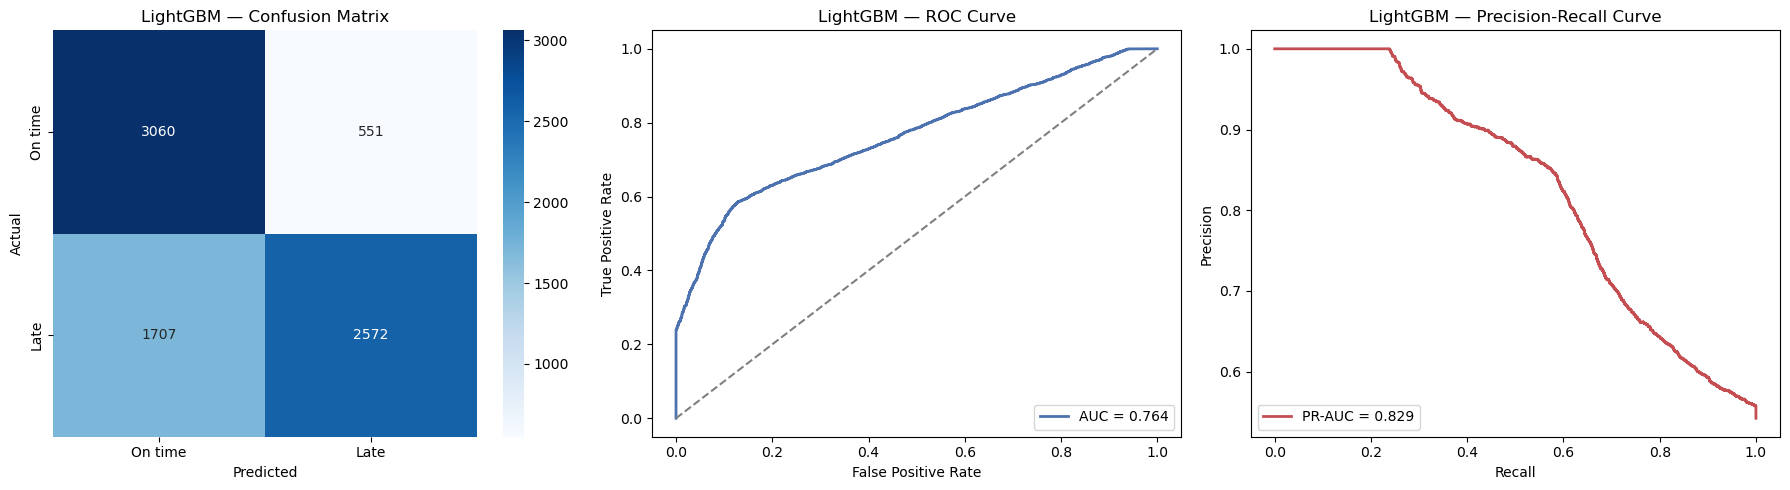

In [4]:
lgbm_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'LightGBM', save_prefix='lightgbm')


**What we found:**

**Almost identical to XGBoost, exactly as expected for two gradient boosted tree implementations on the same data:**

| Metric | XGBoost | LightGBM | Difference |
|---|---|---|---|
| Recall | 0.6062 | 0.6011 | -0.0051 |
| Precision | 0.8160 | 0.8236 | +0.0076 |
| F1 | 0.6956 | 0.6949 | -0.0007 |
| ROC-AUC | 0.7595 | 0.7643 | +0.0048 |
| PR-AUC | 0.8250 | 0.8290 | +0.0040 |

Every difference is under a percentage point, this is essentially a tie, which is the expected and reassuring result: two independent boosting implementations converging to very similar performance is a good consistency signal that the underlying patterns in the data are real, not an artifact of one specific library's quirks. LightGBM edges ahead very slightly on Precision, ROC-AUC, and PR-AUC, while XGBoost edges ahead very slightly on Recall, differences small enough that either could flip with a different random seed or after Stage 8's tuning. Neither model can currently be called the clear winner between them on default settings.


## 3. Feature importances

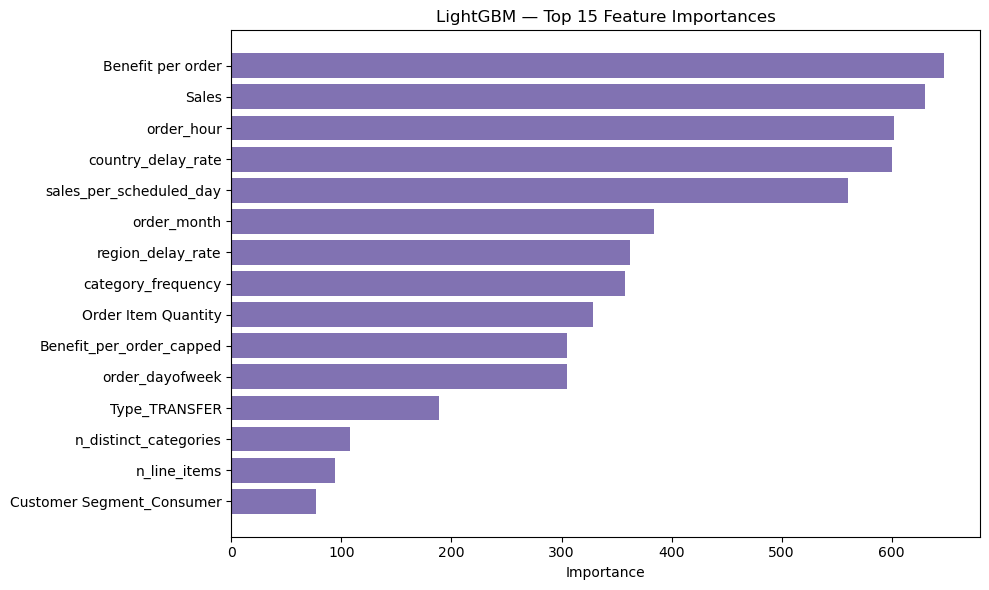

In [5]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': lgbm.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#8172B2')
plt.xlabel('Importance')
plt.title('LightGBM — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../../reports/figures/lightgbm_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found: a real inconsistency worth catching, not a genuine algorithmic difference.**

LightGBM's importance chart looks dramatically different from XGBoost's, `Shipping Mode` doesn't even appear in the top 15 here, dominated instead by `Benefit per order`, `Sales`, `order_hour`, and `country_delay_rate`. That directly contradicts XGBoost's chart, where Shipping Mode accounted for over 90% of total importance, and contradicts everything else found so far (EDA's 57pp spread, Logistic Regression's dominant coefficients).

**This is the same cardinality bias problem we already caught with Random Forest, showing up again under a different name.** `LGBMClassifier`'s default `feature_importances_` uses `importance_type='split'` (how many times a feature is used across all splits), which favors continuous, high cardinality features exactly like RF's MDI importance did, they simply get used in more splits because they offer more possible split points, regardless of whether those splits are actually impactful. XGBoost's chart used gain based importance by default, a genuinely different measure that isn't biased the same way, which is why the two charts look so different even though the models perform almost identically.

**This isn't a genuine disagreement about what matters, it's two different importance metrics measuring different things.** The fix, consistent with how we handled this for Random Forest, is to either recompute with `importance_type='gain'` for a fair comparison against XGBoost, or treat both charts as provisional and rely on Stage 8's SHAP analysis for the real interpretability story. Given we already have a clean example of this exact bias from Random Forest's MDI chart, it's probably not worth spending more time re running LightGBM with a different importance type right now, better to let SHAP settle this properly and consistently across every model at once in Stage 8, rather than patching each model's default importance chart individually.

**Practical note:** this is now the *second* time a tree based model's default importance ranking has looked misleading (Random Forest, then LightGBM). That's worth stating as a pattern in the write up, not a one off, it strengthens the case for why SHAP was the right call to plan for from the start rather than trusting `feature_importances_` at face value anywhere in this project.


## 4. Save model and metrics

In [6]:
joblib.dump(lgbm, '../../../models/lightgbm.pkl')
save_metrics(lgbm_metrics, '../../../data/processed/metrics_lightgbm.json')


Saved metrics to ../../../data/processed/metrics_lightgbm.json
